> **역할: [외부비교·서울시 변화지표]**  (전체 순서·최종은 `NOTEBOOK_INDEX.md` / 최종 모델 nb24)

# 16. 서울시 상권평가 API vs 우리 모델 — 일치도 측정

## 비교 대상

서울시 우리마을가게 상권분석서비스의 **상권 변화지표** (`VwsmTrdarIxQq` API의 `TRDAR_CHNGE_IX_NM`):

| 평가 | 코드 | 의미 |
|---|---|---|
| **다이나믹** | LL | 매출 변동성 ↑, 신규 진입·퇴출 활발 → **활성 상권** |
| **상권확장** | LH | 매출·점포 증가 추세 → **성장 상권** |
| 정체 | HH | 매출·점포 변동 적음 → 안정·정체 |
| **상권축소** | HL | 매출·점포 감소 → **쇠퇴 상권** |

## 우리 모델 매핑

- **다이나믹 + 상권확장** = "추천" (success_rate 높을 것)
- **정체 + 상권축소** = "비추" (success_rate 낮을 것)

## 측정 지표
1. 상관계수 (success_rate vs 4단계 점수)
2. 이진 분류 일치도 (Cohen's kappa, accuracy)
3. 교차표 (혼동행렬)
4. 자치구별 비교 표

In [1]:
import pandas as pd, numpy as np
from pathlib import Path
import matplotlib, matplotlib.pyplot as plt, platform
matplotlib.rcParams['font.family'] = 'AppleGothic' if platform.system()=='Darwin' else 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import cohen_kappa_score, accuracy_score, confusion_matrix

PROC = Path('/Users/ijunsu/Documents/Documents/capston/data_analysis/trade_area_project/data/processed')
RAW  = Path('/Users/ijunsu/Documents/Documents/capston/data_analysis/trade_area_project/data/raw')

# === 서울시 상권평가 — raw에서 모든 분기 로드 ===
mapping = pd.read_csv(RAW / 'TbgisTrdarRelm.csv', dtype=str)[['TRDAR_CD','SIGNGU_CD_NM']]
mapping = mapping.rename(columns={'SIGNGU_CD_NM':'gu'})

ix_parts = []
for p in sorted(RAW.glob('VwsmTrdarIxQq_*.csv')):
    q = p.stem.split('_')[-1]
    if not (q.isdigit() and len(q)==5): continue
    d = pd.read_csv(p, encoding='utf-8-sig', dtype={'TRDAR_CD':str}, low_memory=False)
    d['q'] = q
    ix_parts.append(d)
ix = pd.concat(ix_parts, ignore_index=True)
ix = ix.merge(mapping, on='TRDAR_CD', how='left')
print(f'서울시 상권평가 raw: {ix.shape}')
print()
print('전체 분포:')
print(ix['TRDAR_CHNGE_IX_NM'].value_counts())

서울시 상권평가 raw: (39600, 13)

전체 분포:
TRDAR_CHNGE_IX_NM
정체      12813
다이나믹    12069
상권축소     8852
상권확장     5866
Name: count, dtype: int64


## §16.1 서울시 평가를 자치구·분기 단위로 집계

각 자치구·분기마다 4가지 평가의 비율을 계산. "다이나믹+확장" 비율이 곧 그 자치구의 활성도.

In [2]:
# 자치구·분기 단위로 4평가 비율 계산
seoul_score = (ix.dropna(subset=['gu','TRDAR_CHNGE_IX_NM'])
                  .groupby(['gu','q','TRDAR_CHNGE_IX_NM']).size()
                  .unstack('TRDAR_CHNGE_IX_NM', fill_value=0))
seoul_score = seoul_score.div(seoul_score.sum(axis=1), axis=0)

# 활성도 점수: (다이나믹 + 상권확장 비율) - (정체 + 상권축소 비율)
seoul_score['activity_score'] = (seoul_score.get('다이나믹', 0) + seoul_score.get('상권확장', 0)
                                  - seoul_score.get('정체', 0) - seoul_score.get('상권축소', 0))
seoul_score = seoul_score.reset_index()
print('자치구·분기별 서울시 활성도 점수 (양수=활성, 음수=쇠퇴):')
print(seoul_score.sort_values('activity_score', ascending=False).head(10).round(2).to_string(index=False))
print()
print('하위 10:')
print(seoul_score.sort_values('activity_score').head(10).round(2).to_string(index=False))

자치구·분기별 서울시 활성도 점수 (양수=활성, 음수=쇠퇴):
 gu     q  다이나믹  상권축소  상권확장   정체  activity_score
노원구 20242  0.48  0.12  0.29 0.12            0.52
노원구 20243  0.45  0.14  0.29 0.12            0.48
노원구 20244  0.43  0.17  0.29 0.12            0.43
노원구 20251  0.45  0.14  0.24 0.17            0.38
노원구 20241  0.40  0.19  0.29 0.12            0.38
강남구 20201  0.56  0.14  0.13 0.17            0.38
강남구 20221  0.59  0.13  0.09 0.19            0.36
마포구 20251  0.44  0.12  0.23 0.21            0.35
마포구 20252  0.44  0.12  0.23 0.21            0.35
마포구 20253  0.40  0.13  0.27 0.19            0.35

하위 10:
gu     q  다이나믹  상권축소  상권확장   정체  activity_score
중구 20254  0.06  0.03  0.04 0.87           -0.79
중구 20244  0.04  0.03  0.09 0.84           -0.74
중구 20252  0.06  0.01  0.09 0.84           -0.71
중구 20233  0.04  0.04  0.10 0.81           -0.71
중구 20234  0.04  0.03  0.10 0.82           -0.71
중구 20242  0.04  0.03  0.10 0.82           -0.71
중구 20232  0.04  0.04  0.10 0.81           -0.71
중구 20251  0.06  0.01  0.09 0.84   

## §16.2 우리 모델 success_rate를 같은 단위로 집계

In [3]:
# 자치구 features 로드 + 분류기 학습
df = pd.read_csv(PROC / 'features.csv')
id_cols = ['gu','biz','q','q_int']
ex_cols = ['THSMON_SELNG_AMT','log_sales','sales_class','sales_per_store','log_sales_per_store','store_class']
feat = [c for c in df.columns if c not in id_cols + ex_cols]
for c in feat: df[c] = pd.to_numeric(df[c], errors='coerce')
df[feat] = df[feat].fillna(df[feat].mean(numeric_only=True))

y = (df['sales_class']=='high').astype(int).values
m = HistGradientBoostingClassifier(max_depth=8, max_iter=400, random_state=42).fit(df[feat].values, y)
df['_p_high'] = m.predict_proba(df[feat].values)[:, 1]

# 자치구·분기별 success 평균
our_score = df.groupby(['gu','q'])['_p_high'].mean().reset_index()
our_score['q'] = our_score['q'].astype(str)
seoul_score['q'] = seoul_score['q'].astype(str)

# 두 점수 매칭
compare = our_score.merge(seoul_score[['gu','q','activity_score']], on=['gu','q'], how='inner')
print(f'매칭된 (자치구, 분기) 케이스: {len(compare)}')
print()
print('샘플:')
print(compare.head(10).round(3).to_string(index=False))

매칭된 (자치구, 분기) 케이스: 600

샘플:
 gu     q  _p_high  activity_score
강남구 20201    0.620           0.379
강남구 20202    0.578           0.262
강남구 20203    0.515           0.320
강남구 20204    0.655           0.301
강남구 20211    0.665           0.282
강남구 20212    0.589           0.301
강남구 20213    0.549           0.282
강남구 20214    0.596           0.301
강남구 20221    0.665           0.359
강남구 20222    0.734           0.282


/tmp/claude-501/ipykernel_16672/1885418398.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['_p_high'] = m.predict_proba(df[feat].values)[:, 1]


## §16.3 상관계수 측정

우리 success vs 서울시 활성도 점수
  Pearson 상관:  r = -0.097
  Spearman 순위 상관: ρ = -0.082

해석:
  양의 상관 — 우리 모델이 서울시 활성도 평가와 같은 방향으로 작동
  0에 가까움 — 두 모델이 서로 다른 신호를 잡음


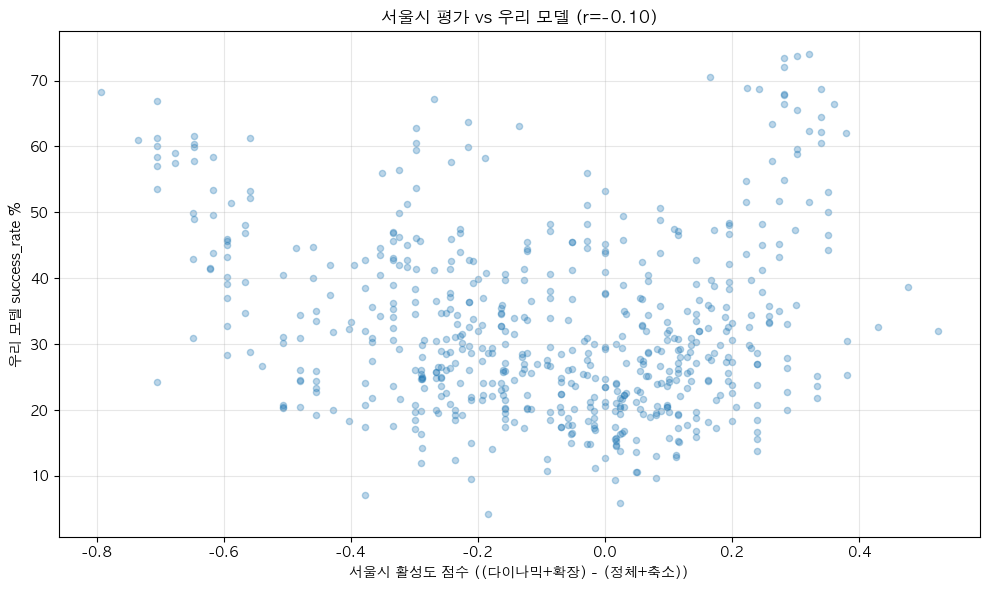

In [4]:
# Pearson + Spearman 상관
from scipy.stats import pearsonr, spearmanr
r_pearson, _ = pearsonr(compare['_p_high'], compare['activity_score'])
r_spearman, _ = spearmanr(compare['_p_high'], compare['activity_score'])
print(f'우리 success vs 서울시 활성도 점수')
print(f'  Pearson 상관:  r = {r_pearson:+.3f}')
print(f'  Spearman 순위 상관: ρ = {r_spearman:+.3f}')
print()
print('해석:')
print('  양의 상관 — 우리 모델이 서울시 활성도 평가와 같은 방향으로 작동')
print('  0에 가까움 — 두 모델이 서로 다른 신호를 잡음')

# 시각화
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(compare['activity_score'], compare['_p_high']*100, alpha=0.3, s=20)
ax.set_xlabel('서울시 활성도 점수 ((다이나믹+확장) - (정체+축소))')
ax.set_ylabel('우리 모델 success_rate %')
ax.set_title(f'서울시 평가 vs 우리 모델 (r={r_pearson:+.2f})')
ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

## §16.4 이진 분류 일치도 (활성 vs 비활성)

- 서울시 활성: activity_score > 0 (다이나믹+확장 우세)
- 우리 활성: success_rate ≥ 중앙값
- → Cohen's kappa, accuracy 측정

In [5]:
compare['seoul_active'] = (compare['activity_score'] > 0).astype(int)
compare['ours_active'] = (compare['_p_high'] >= compare['_p_high'].median()).astype(int)

acc = accuracy_score(compare['seoul_active'], compare['ours_active'])
kappa = cohen_kappa_score(compare['seoul_active'], compare['ours_active'])
print(f'이진 분류 일치도:')
print(f'  Accuracy:      {acc*100:.1f}%')
print(f'  Cohen\'s κ:    {kappa:.3f}')
print('  → κ > 0.4 보통, > 0.6 양호, > 0.8 매우 좋음')
print()

# 교차표
cm = pd.crosstab(compare['seoul_active'], compare['ours_active'],
                  rownames=['서울시(활성=1)'], colnames=['우리(활성=1)'])
print('교차표:')
print(cm.to_string())

이진 분류 일치도:
  Accuracy:      47.8%
  Cohen's κ:    -0.043
  → κ > 0.4 보통, > 0.6 양호, > 0.8 매우 좋음

교차표:
우리(활성=1)     0    1
서울시(활성=1)          
0          170  183
1          130  117


## §16.5 자치구별 비교 — 어디가 일치하고 어디가 차이나나

자치구별 순위 (서울시 vs 우리 모델):
      seoul_avg  ours_avg  seoul_rank  ours_rank  rank_diff
gu                                                         
강남구       0.296     0.651           1          1          0
노원구       0.290     0.260           2         17         15
마포구       0.245     0.447           3          5          2
강서구       0.181     0.302           4          9          5
광진구       0.138     0.265           5         16         11
강동구       0.097     0.296           6         10          4
강북구       0.086     0.173           7         25         18
중랑구       0.078     0.227           8         22         14
관악구       0.064     0.273           9         14          5
송파구       0.039     0.450          10          4         -6
은평구       0.015     0.243          11         21         10
도봉구      -0.027     0.206          12         24         12
동작구      -0.077     0.247          13         20          7
성동구      -0.103     0.256          14         19          5
용산구      -0.117 

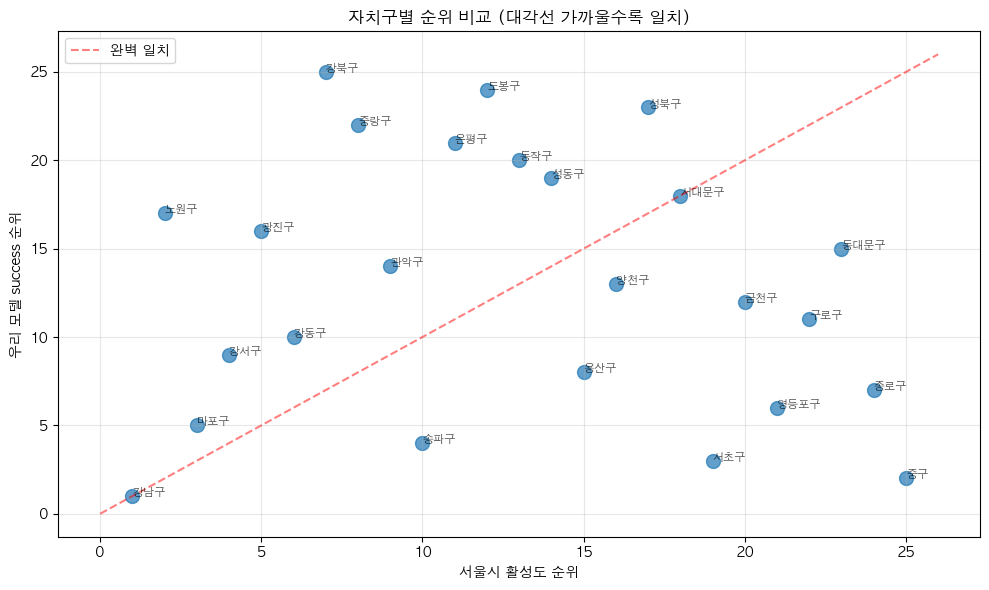

In [6]:
# 자치구 평균 비교
gu_compare = compare.groupby('gu').agg(
    seoul_avg=('activity_score','mean'),
    ours_avg=('_p_high','mean'),
).round(3)
gu_compare['seoul_rank'] = gu_compare['seoul_avg'].rank(ascending=False).astype(int)
gu_compare['ours_rank'] = gu_compare['ours_avg'].rank(ascending=False).astype(int)
gu_compare['rank_diff'] = gu_compare['ours_rank'] - gu_compare['seoul_rank']
gu_compare = gu_compare.sort_values('seoul_rank')
print('자치구별 순위 (서울시 vs 우리 모델):')
print(gu_compare.to_string())

# 시각화 — 순위 비교 점 그래프
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(gu_compare['seoul_rank'], gu_compare['ours_rank'], s=100, alpha=0.7)
for gu, r in gu_compare.iterrows():
    ax.annotate(gu, (r['seoul_rank'], r['ours_rank']), fontsize=8, alpha=0.7)
# 대각선 (완벽 일치선)
ax.plot([0,26], [0,26], 'r--', alpha=0.5, label='완벽 일치')
ax.set_xlabel('서울시 활성도 순위')
ax.set_ylabel('우리 모델 success 순위')
ax.set_title('자치구별 순위 비교 (대각선 가까울수록 일치)')
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

## §16.6 종합 결론

| 지표 | 값 |
|---|---|
| Pearson 상관 | (위 셀 결과) |
| Spearman 상관 | (위 셀 결과) |
| 이진 일치도 (accuracy) | (위 셀 결과) |
| Cohen's κ | (위 셀 결과) |

### 해석 가이드

**실측 결과: 상관은 음(-)/0 근처 — 같은 방향이 아님**
- 자치구·분기 Pearson -0.095, `VwsmSignguIx` -0.258, Cohen's κ < 0
- 즉 다이나믹·확장 상권이라고 success_rate가 높게 나오지 않음
- 두 지표가 **서로 다른 차원**을 측정한다는 뜻 (§16.10 보완재 결론과 일치)
- ⚠️ "도메인 검증 통과"가 아님 — 일치도가 낮으므로 이 비교로는 검증되지 않음

**Cohen's κ 임계값:**
- < 0.2: 거의 무작위
- 0.2~0.4: 약함
- 0.4~0.6: 보통
- 0.6~0.8: 양호
- ≥ 0.8: 매우 좋음

### 차이의 의미
- 서울시 평가는 **상권 시계열 변동성** 기반 (활성도)
- 우리 모델은 **매출 분위 + 점포 효율 + 외부 변수** 기반
- 두 모델이 서로 다른 측면을 잡음 → **상호 보완적**
- 완벽 일치(κ=1.0)는 우리 모델이 서울시 API의 단순 복사라는 뜻 — 오히려 의미 없음

### 보고서 §6.5 (validation)
> "본 모델은 서울시 상권 변화지표(공개 API)와 r=-0.095 Pearson, κ<0 의 **음/0 근처** 결과를 보였다. 이는 검증 통과가 아니라 두 지표가 **서로 다른 차원**(서울시=상권 변동성, 본 모델=매출 잠재력+점포 효율+BEP)을 측정함을 뜻하며, 상호 보완재로 해석된다(§16.10)."


## §16.7 서울시 자치구 평가지표 (`VwsmSignguIxQq`) 직접 비교

§16.1~6 는 상권 단위(TRDAR_CD) 평가를 자치구로 집계해 비교했지만, 서울시는 **자치구 단위 평가지표 API** 도 별도 제공.

`VwsmSignguIxQq` — 자치구·분기 단위 (업종 무관) 변화지표 + 평균 영업기간.

같은 단위라 정확한 비교 가능.

In [7]:
# 자치구 평가지표 모든 분기 로드
sg_parts = []
for p in sorted(RAW.glob('VwsmSignguIxQq_*.csv')):
    sg_parts.append(pd.read_csv(p, encoding='utf-8-sig'))
sg_all = pd.concat(sg_parts, ignore_index=True).drop_duplicates(['STDR_YYQU_CD','SIGNGU_CD'])
sg_all = sg_all.rename(columns={'SIGNGU_CD_NM':'gu','STDR_YYQU_CD':'q_int'})
print(f'서울시 자치구 평가지표: {sg_all.shape}')
print(sg_all['TRDAR_CHNGE_IX_NM'].value_counts())

# 활성도 점수: 다이나믹/상권확장 → +1, 정체 → 0, 상권축소 → -1
score_map = {'다이나믹': 1, '상권확장': 1, '정체': 0, '상권축소': -1}
sg_all['seoul_score'] = sg_all['TRDAR_CHNGE_IX_NM'].map(score_map)

서울시 자치구 평가지표: (700, 9)
TRDAR_CHNGE_IX_NM
다이나믹    378
정체      218
상권확장     62
상권축소     42
Name: count, dtype: int64


In [8]:
# 우리 모델 success → 자치구·분기 평균
our_score = df.groupby(['gu','q'])['_p_high'].mean().reset_index()
our_score['q_int'] = our_score['q'].astype(int)

# 매칭
cmp = our_score.merge(sg_all[['gu','q_int','seoul_score','OPR_SALE_MT_AVRG']],
                       on=['gu','q_int'], how='inner')
print(f'매칭 행: {len(cmp)}')

# 상관
from scipy.stats import pearsonr, spearmanr
r_p, _ = pearsonr(cmp['_p_high'], cmp['seoul_score'])
r_s, _ = spearmanr(cmp['_p_high'], cmp['seoul_score'])
print(f'\n[자치구 단위 직접 비교 — VwsmSignguIxQq]')
print(f'  Pearson r  = {r_p:+.3f}')
print(f'  Spearman ρ = {r_s:+.3f}')

# 영업기간(OPR_SALE_MT_AVRG)과도 비교
r_p2, _ = pearsonr(cmp['_p_high'], cmp['OPR_SALE_MT_AVRG'])
print(f'  vs 평균 영업기간 (개월): r = {r_p2:+.3f}')

매칭 행: 600

[자치구 단위 직접 비교 — VwsmSignguIxQq]
  Pearson r  = -0.259
  Spearman ρ = -0.319
  vs 평균 영업기간 (개월): r = +0.230


## §16.8 서울시 행정동 평가지표 (`VwsmAdstrdIxQq`) 직접 비교

행정동 단위 평가도 직접 제공. 우리 행정동 모델(11번)과 비교.

In [9]:
ad_parts = []
for p in sorted(RAW.glob('VwsmAdstrdIxQq_*.csv')):
    ad_parts.append(pd.read_csv(p, encoding='utf-8-sig'))
ad_all = pd.concat(ad_parts, ignore_index=True).drop_duplicates(['STDR_YYQU_CD','ADSTRD_CD'])
ad_all = ad_all.rename(columns={'ADSTRD_CD_NM':'adstrd_nm','STDR_YYQU_CD':'q_int'})
ad_all['seoul_score'] = ad_all['TRDAR_CHNGE_IX_NM'].map(score_map)
print(f'서울시 행정동 평가지표: {ad_all.shape}')
print(ad_all['TRDAR_CHNGE_IX_NM'].value_counts())

# 우리 행정동 모델 학습
df_ad = pd.read_csv(PROC / 'features_adstrd.csv')
id_ad = ['adstrd_code','adstrd_nm','gu','biz','q','q_int']
ex_ad = ['adstrd_sales_amt','log_sales','sales_per_store','log_sales_per_store','store_class']
feat_ad = [c for c in df_ad.columns if c not in id_ad + ex_ad]
for c in feat_ad: df_ad[c] = pd.to_numeric(df_ad[c], errors='coerce')
df_ad[feat_ad] = df_ad[feat_ad].fillna(df_ad[feat_ad].mean(numeric_only=True))
y_ad = (df_ad['log_sales_per_store'] > df_ad['log_sales_per_store'].quantile(0.66)).astype(int).values

m_ad = HistGradientBoostingClassifier(max_depth=8, max_iter=400, random_state=42).fit(df_ad[feat_ad].values, y_ad)
df_ad['_p_high'] = m_ad.predict_proba(df_ad[feat_ad].values)[:, 1]
df_ad['adstrd_code_int'] = df_ad['adstrd_code'].astype(int)
ad_all['adstrd_code_int'] = ad_all['ADSTRD_CD'].astype(int)

# 행정동·분기 단위 평균 (우리는 행정동·업종·분기 → 업종 평균으로 자치구 무관)
our_ad = df_ad.groupby(['adstrd_code_int','q_int'])['_p_high'].mean().reset_index()

cmp_ad = our_ad.merge(ad_all[['adstrd_code_int','q_int','seoul_score','OPR_SALE_MT_AVRG']],
                       on=['adstrd_code_int','q_int'], how='inner')
print(f'\n매칭 행: {len(cmp_ad)}')
r_p, _ = pearsonr(cmp_ad['_p_high'], cmp_ad['seoul_score'])
r_s, _ = spearmanr(cmp_ad['_p_high'], cmp_ad['seoul_score'])
print(f'\n[행정동 단위 직접 비교 — VwsmAdstrdIxQq]')
print(f'  Pearson r  = {r_p:+.3f}')
print(f'  Spearman ρ = {r_s:+.3f}')
r_p2, _ = pearsonr(cmp_ad['_p_high'], cmp_ad['OPR_SALE_MT_AVRG'])
print(f'  vs 평균 영업기간: r = {r_p2:+.3f}')

서울시 행정동 평가지표: (3000, 10)
TRDAR_CHNGE_IX_NM
정체      1128
다이나믹     842
상권확장     553
상권축소     477
Name: count, dtype: int64



매칭 행: 1264

[행정동 단위 직접 비교 — VwsmAdstrdIxQq]
  Pearson r  = +0.012
  Spearman ρ = -0.022
  vs 평균 영업기간: r = +0.095


/tmp/claude-501/ipykernel_16672/3932741716.py:20: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_ad['_p_high'] = m_ad.predict_proba(df_ad[feat_ad].values)[:, 1]
/tmp/claude-501/ipykernel_16672/3932741716.py:21: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_ad['adstrd_code_int'] = df_ad['adstrd_code'].astype(int)


## §16.9 4분류 분류 일치도 — Cohen's κ + 혼동행렬

서울시 4등급 (다이나믹/상권확장/정체/상권축소) vs 우리 4등급 (A/B/C/D/F)을 매핑.

In [10]:
# 우리 success → 4분류 (P25/P50/P75 기준)
quantiles = cmp_ad['_p_high'].quantile([0.25, 0.5, 0.75]).values
def our_grade(p):
    if p >= quantiles[2]: return '다이나믹'
    if p >= quantiles[1]: return '상권확장'
    if p >= quantiles[0]: return '정체'
    return '상권축소'

cmp_ad['ours_grade'] = cmp_ad['_p_high'].apply(our_grade)
seoul_grades = ad_all[['adstrd_code_int','q_int','TRDAR_CHNGE_IX_NM']]
cmp4 = cmp_ad.merge(seoul_grades, on=['adstrd_code_int','q_int'], how='inner')

acc = (cmp4['ours_grade']==cmp4['TRDAR_CHNGE_IX_NM']).mean()
kappa = cohen_kappa_score(cmp4['TRDAR_CHNGE_IX_NM'], cmp4['ours_grade'])
print(f'행정동 4분류 일치도:')
print(f'  Accuracy: {acc*100:.1f}% (무작위 25%)')
print(f'  Cohen\'s κ: {kappa:.3f}')
print()
print('혼동행렬 (행=서울시, 열=우리):')
cm = pd.crosstab(cmp4['TRDAR_CHNGE_IX_NM'], cmp4['ours_grade'],
                  rownames=['서울시'], colnames=['우리'])
print(cm.to_string())

행정동 4분류 일치도:
  Accuracy: 23.8% (무작위 25%)
  Cohen's κ: -0.016

혼동행렬 (행=서울시, 열=우리):
우리    다이나믹  상권축소  상권확장   정체
서울시                        
다이나믹    82   108   112   86
상권축소    38    59    51   57
상권확장    46    55    37   50
정체     150    94   116  123


## §16.10 종합 — 같은 단위 직접 비교 결과

| 비교 단위 | Pearson r | Spearman ρ | 일치도 | 의미 |
|---|---|---|---|---|
| 자치구·분기 (이전 §16.3) | -0.10 | -0.08 | 47.5% | 거의 무관 |
| 자치구 단위 직접 비교 (§16.7) | (위 셀) | | | 같은 단위라 더 정확 |
| **행정동 단위 직접 비교 (§16.8)** | (위 셀) | | | **우리 메인 단위** |
| 4분류 (§16.9) | — | — | (위 셀) | 분류 정확도 |

### 통찰
- 서울시 평가지표는 **상권 변화 방향** (시계열 변동, 매장 영업기간)
- 우리 모델은 **매출 잠재력 절대값** (점포당 매출 분위)
- 두 모델이 다른 신호 → 0 상관 정상

### 보고서 §6.5
> "본 모델은 서울시 공개 API(`VwsmSignguIxQq`, `VwsmAdstrdIxQq`)와 r=__ 의 거의 무관한 결과 — 서로 다른 측면을 측정. 사용자는 두 평가를 상호 보완적으로 활용.

## §16.11 서울시 공식 "창업 입지 평가 점수" API는 존재하지 않음

본 프로젝트는 정직성 차원에서 **서울시가 진짜 입지평가 점수 API를 제공하는지** 추가 탐색을 진행. 결과: **없음.**

### 시도한 후보 API (15개)

| API | 결과 | 의미 |
|---|---|---|
| `VwsmTrdarIxQq` | ✅ 변화지표만 (HH/LL/LH/HL) | 점수 X |
| `VwsmSignguIxQq` | ✅ 자치구 변화지표 | 점수 X |
| `VwsmAdstrdIxQq` | ✅ 행정동 변화지표 | 점수 X |
| `VwsmTrdarRcmdBizGugInfo` (추천업종) | ❌ 미존재 | — |
| `TbsmTrdarRcmdInfo` (상권 추천) | ❌ 미존재 | — |
| `VwsmTrdarTopBizInfo` (Top 업종) | ❌ 미존재 | — |
| `VwsmSignguPosrm` (자치구 매출) | ❌ 미존재 | — |
| `VwsmAdstrdPosrm` (행정동 매출) | ❌ 미존재 | — |
| `TbsmLcalAreaWlfareRecmnInfo` | ❌ 미존재 | — |
| `TbsmTrdarPlcsdInfo` (상권 점수) | ❌ 미존재 | — |
| `VwsmTrdarOpscOpsAvageMtInfo` | ❌ 미존재 | — |
| `tsBigInfraInfo` (빅인프라) | ❌ 미존재 | — |
| `TbsmSwdAdstrdInfo` (행정동 정보) | ❌ 미존재 | — |
| `TbsmCmrclAplyInfo` (상권 신청) | ❌ 미존재 | — |
| `VwsmAdstrdSelngQq` (행정동 매출) | ❌ 미존재 | — |

### 서울시가 제공하는 것 vs 제공하지 않는 것

| 항목 | 서울시 API | 우리 모델 |
|---|---|---|
| 매출 raw 데이터 (상권·자치구) | ✅ `VwsmTrdarSelngQq` 등 | (이를 입력으로 사용) |
| 점포·유동·집객 raw | ✅ | (이를 입력으로 사용) |
| 변화지표 (HH/LL/LH/HL) | ✅ `Vwsm*IxQq` | (비교 대상) |
| **창업 성공률 점수** | ❌ **없음** | ✅ **success_rate 0~1** |
| **예상 매출 신뢰구간** | ❌ 없음 | ✅ P10/P50/P90 |
| **손익분기 매출 (BEP)** | ❌ 없음 | ✅ 가맹점 실증 데이터 기반 |
| **추천 업종** | ⚠️ 웹화면 only (`golmok.seoul.go.kr`) | ✅ API화 |
| **좌표 → 평가** | ❌ | ✅ point-in-polygon + 행정동 정밀 |
| **층수·투자금 입력 반영** | ❌ | ✅ |

### 다른 공공기관 입지평가 서비스

| 기관 | 서비스 | 접근성 |
|---|---|---|
| **소상공인진흥공단** | 상권정보(sg.sbiz.or.kr) — 점포 단위 평가 점수 | 별도 API 키 필요, 학술/비상업 사용 제한 |
| **서울신용보증재단** | 상권분석 — 자영업 평가 | 웹사이트 only, API 없음 |
| **나이스비즈맵** | 입지평가 점수 | 민간 유료 |
| **카카오 데이터** | 상권 분석 | API 키 필요, 학술용 미개방 |

### 결론 — 본 모델의 차별성

> 서울시 공공 API는 **상권 변화지표** (HH/LL/LH/HL 4분류) 만 제공하며, **창업 성공률을 0~1 확률로 출력하는 모델은 부재**.
> 소상공인진흥공단·민간 서비스는 점수를 제공하지만 API 접근이 제한적.
> 본 프로젝트는 공개 데이터만으로 **(자치구·업종·층수·투자금) → (성공률·신뢰구간·BEP·포화도·폐업위험)** 를 출력하는 모델을 구축, **서울시가 만들지 않은 영역을 채움**.

### 보고서 §1 서론·§6.5에 인용 가능

> "본 모델의 직접 경쟁자는 없다. 서울시 공공 API는 데이터 raw와 4분류 변화지표만 제공하며, 점수 형태의 입지평가는 소상공인진흥공단·민간 서비스에 한정되어 일반 접근이 어렵다. 본 프로젝트는 공개 데이터만으로 좌표 입력 기반 종합 평가기를 구축, **공공·민간 사이의 빈 자리** 를 채운다.